# Functional roles (task 6.4)

Every card in the pool gets **one primary and an optional secondary functional role**, so a deck
can be described as *role counts* — "11 mana sources, 8 draw, 5 spot removal, 36 lands" — instead
of as a bag of 99 names. Task 6.6's archetype quotas and the cut recommender both need that: you
cannot say "you are two pieces of interaction short" without first defining a piece of interaction.

Module: [`edhcut/analysis/roles.py`](../edhcut/analysis/roles.py) → `data/kb/dev/roles.parquet`.
Full write-up, including every vocabulary decision and why:
[`docs/devlog/6.4-functional-roles.md`](../docs/devlog/6.4-functional-roles.md).

## The 18 roles

| role | what it means |
|---|---|
| `land` | occupies a land slot — a **type-line override**, so a functional land's role becomes its *secondary* |
| `stax` | Winter Orb, Blood Moon — **plus all mass land destruction, and land destruction that gives nothing back** (Armageddon, Stone Rain, Wasteland) |
| `boardwipe` | Wrath of God |
| `stack_interaction` | countering, copying, redirecting, granting flash, granting "can't be countered", denying opponents the stack |
| `spot_removal` | Swords to Plowshares — including land destruction that *replaces* the land (Ghost Quarter) or could have hit a nonland (Acidic Slime) |
| `sacrifice_outlet` | Ashnod's Altar, Viscera Seer |
| `tutor` | Demonic Tutor |
| `mana_acceleration` | Sol Ring, Cultivate, Dark Ritual, **and cost reducers**. Not colour fixing |
| `draw` | Rhystic Study, impulse draw, **loot and rummage**. **Not cantrips** |
| `recursion` | Eternal Witness |
| `graveyard_hate` | Bojuka Bog |
| `protection` | keeps **your permanents** alive |
| `defensive` | keeps **you** alive: fogs, lifegain, pillowfort, goad |
| `wincon` | damage aimed at players, extra turns, extra combats, one-shot board buffs, and lords that grant evasion or scale |
| `evasion` | grants evasion to others |
| `enhancer` | doublers, increasers, extra phases, counter manipulation |
| `board_presence` | token makers, lords, +1/+1 counter distributors, genuinely big bodies |
| `other` | the only default: nothing on this list fits |

**Declared precedence** where a card does several at once: `stax` > `boardwipe` > `graveyard_hate`
(Decree of Annihilation does all three), and `wincon` > `board_presence` (a lord that grants evasion
closes games; a plain lord builds a board).

**§5 is the part to actually use** — helpers for filtering by role, Scryfall tag, secondary role
or play count; `explain()` for why any single card got what it got; four purpose-built tools for
finding cards the mapping got wrong; and `deck_breakdown()` for one of my own decklists.

## 1. Setup

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

from edhcut.analysis import roles as R
from edhcut.config import CONFIG
from edhcut.db import connect
from edhcut.ingest.edhrec import resolve_oracle_id

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

# Keep the context-manager object itself alive (not just the yielded `conn`) -- otherwise the
# generator-based context manager can get garbage-collected mid-notebook and close the connection
# out from under later cells.
_db_ctx = connect(CONFIG.paths.db_path)
conn = _db_ctx.__enter__()

# `cards` is the single frame everything in this notebook reads: one row per card, its roles, and
# enough context (deck count, image) to look at it.
roles = R.assign_roles(conn)
extra = pd.DataFrame(
    conn.execute("SELECT oracle_id, image_uri, cmc FROM cards").fetchall(),
    columns=["oracle_id", "image_uri", "cmc"])
played = pd.DataFrame(
    conn.execute("SELECT oracle_id, COUNT(DISTINCT deck_id) AS deck_count "
                 "FROM deck_cards GROUP BY oracle_id").fetchall(),
    columns=["oracle_id", "deck_count"])
cards = roles.merge(extra, on="oracle_id", how="left").merge(played, on="oracle_id", how="left")
cards["deck_count"] = cards["deck_count"].fillna(0).astype(int)

# Tags, kept in memory so the exploration helpers can filter on them without a query per card.
tags_by_card = R.load_card_tags(conn)
tag_counts = pd.Series([t for ts in tags_by_card.values() for t in ts]).value_counts().to_dict()
mapped_tags = {t for rules in R.TAG_RULES.values() for t in rules}

print(f"{len(cards):,} cards | {len(tag_counts):,} distinct Scryfall tags | "
      f"{len(mapped_tags)} of them used by the mapping")

31,830 cards | 4,183 distinct Scryfall tags | 157 of them used by the mapping


### Exploration helpers

Defined up front so every section below can use them. **The index of what they all do is in
§5** — that is the section to read when you want to explore by hand.

In [2]:
import difflib


def role_label(row) -> str:
    sec = row.get("secondary_role")
    return row["primary_role"] if pd.isna(sec) else f'{row["primary_role"]} / {sec}'


# ------------------------------------------------------------------------------------
# Selecting cards
# ------------------------------------------------------------------------------------


def find(role=None, secondary=None, tag=None, name=None, source=None,
         min_decks=0, max_decks=None, has_secondary=None, sort="decks", limit=None):
    # The one filter everything else is built on. Every argument is optional and they AND
    # together, so find(role="draw", tag="loot") is "draw cards Tagger calls loot".
    #
    #   role         primary role, or a list of them: "draw", ["stax", "boardwipe"]
    #   secondary    secondary role, same forms
    #   has_secondary  True/False -- has any secondary at all
    #   tag          a Scryfall Tagger tag. SUBSTRING match, so "sacrifice" catches every
    #                sacrifice-outlet-* variant at once
    #   name         substring of the card name, case-insensitive
    #   source       which layer assigned the primary: tagger_bulk / heuristic / both /
    #                type_line / default
    #   min_decks    how many corpus decks run it -- the fastest way to skip the long tail
    #   sort         "decks" (default), "score", "name", "role", or any column name.
    #                Prefix with "-" to reverse: sort="-score" is weakest-first, which is
    #                where misclassifications live
    #
    # Returns a DataFrame. Pass it straight to show() to see the cards.
    sub = cards
    if role is not None:
        sub = sub[sub["primary_role"].isin([role] if isinstance(role, str) else role)]
    if secondary is not None:
        sub = sub[sub["secondary_role"].isin([secondary] if isinstance(secondary, str) else secondary)]
    if has_secondary is not None:
        sub = sub[sub["secondary_role"].notna() == has_secondary]
    if tag is not None:
        sub = sub[sub["oracle_id"].map(lambda oid: any(tag in t for t in tags_by_card.get(oid, ())))]
    if name is not None:
        sub = sub[sub["name"].str.contains(name, case=False, regex=False)]
    if source is not None:
        sub = sub[sub["primary_source"] == source]
    sub = sub[sub["deck_count"] >= min_decks]
    if max_decks is not None:
        sub = sub[sub["deck_count"] <= max_decks]

    ascending = sort.startswith("-")
    key = sort.lstrip("-")
    key = {"decks": "deck_count", "score": "primary_score", "role": "primary_role",
           "name": "name"}.get(key, key)
    sub = sub.sort_values([key, "deck_count"], ascending=[ascending, False])
    return (sub if limit is None else sub.head(limit)).reset_index(drop=True)


def find_card(query):
    # One card by name -- exact, then case-insensitive substring, then fuzzy.
    hit = cards[cards["name"].str.lower() == query.lower()]
    if len(hit):
        return hit.iloc[0]
    hit = cards[cards["name"].str.contains(query, case=False, regex=False)]
    if len(hit):
        return hit.nlargest(1, "deck_count").iloc[0]
    close = difflib.get_close_matches(query, cards["name"].tolist(), n=3, cutoff=0.6)
    raise KeyError(f"{query!r} not found." + (f" Did you mean: {', '.join(close)}?" if close else ""))


# ------------------------------------------------------------------------------------
# Looking at them
# ------------------------------------------------------------------------------------


def show(df, title=None, limit=60, width=150, caption=None):
    # Render anything find() returns as a grid of card images -- the default way to look at cards
    # in this project. Accepts a DataFrame, a single row, or a bare name string.
    #
    # Images are hotlinked from Scryfall's CDN via cards.image_uri (task 5.2 stores the URL, so no
    # API call is needed). Fine for occasional/UI use per Scryfall's own guidelines.
    if isinstance(df, str):
        df = find(name=df)
    if isinstance(df, pd.Series):
        df = df.to_frame().T
    if caption is None:
        def caption(r):
            return (f'{role_label(r)}<br><span style="color:#888">'
                    f'{r["primary_score"]:.1f} · {r["deck_count"]:,} decks</span>')
    head = df.head(limit)
    if title or len(df) > limit:
        more = (f" &mdash; showing {len(head)} of {len(df):,}" if len(df) > limit
                else f" ({len(df):,})")
        display(HTML(f'<h4 style="margin:14px 0 6px">{title or "cards"}'
                     f'<span style="font-weight:400;color:#888">{more}</span></h4>'))
    if head.empty:
        display(HTML('<p style="color:#888">(none)</p>'))
        return
    tiles = []
    for _, row in head.iterrows():
        uri = row.get("image_uri")
        img = (f'<img src="{uri}" width="{width}" style="border-radius:7px;display:block">'
               if isinstance(uri, str) else
               f'<div style="width:{width}px;height:{int(width * 1.4)}px;background:#eee;'
               f'border-radius:7px"></div>')
        tiles.append(f'<div style="width:{width}px;margin:0 8px 12px 0;font-size:11px;'
                     f'line-height:1.3">{img}<div style="margin-top:3px">{caption(row)}</div></div>')
    display(HTML(f'<div style="display:flex;flex-wrap:wrap;align-items:flex-start">'
                 f'{"".join(tiles)}</div>'))


# ------------------------------------------------------------------------------------
# Surveying a role
# ------------------------------------------------------------------------------------


def list_roles():
    # Every role with its counts and a few of its most-played members -- the index to start from.
    rows = []
    for role in R.ROLES:
        sub = cards[cards["primary_role"] == role]
        rows.append({
            "role": role,
            "primary": len(sub),
            "secondary": int((cards["secondary_role"] == role).sum()),
            "median_score": round(sub["primary_score"].median(), 1) if len(sub) else 0.0,
            "examples": ", ".join(sub.nlargest(4, "deck_count")["name"]),
        })
    return pd.DataFrame(rows)


def survey(role, n=12, width=130):
    # A role at three depths at once: its most-played cards, its weakest-scoring cards, and the
    # cards the two layers disagreed about. Misclassifications concentrate in the last two, so
    # this is the fastest single call for "does this category look right".
    sub = find(role=role)
    print(f"{role}: {len(sub):,} primary, {int((cards['secondary_role'] == role).sum()):,} "
          f"secondary, score {sub['primary_score'].min():.1f}-{sub['primary_score'].max():.1f} "
          f"(median {sub['primary_score'].median():.1f})")
    show(sub, f"{role} — most played", limit=n, width=width)
    show(find(role=role, sort="-score", min_decks=20),
         f"{role} — weakest evidence (≥20 decks)", limit=n, width=width)
    show(disagreements(role, min_decks=20),
         f"{role} — the two layers disagreed (≥20 decks)", limit=n, width=width)


def role_of_tag(tag, limit=25):
    # Which roles do the cards carrying a Scryfall tag end up in? The fastest way to check a tag
    # is doing what you think: role_of_tag("sacrifice-outlet") should be mostly sacrifice_outlet,
    # and whatever else shows up is worth a look.
    ids = {oid for oid, ts in tags_by_card.items() if any(tag in t for t in ts)}
    sub = cards[cards["oracle_id"].isin(ids)]
    print(f"{len(sub):,} cards match tag ~{tag!r}")
    return (sub.groupby("primary_role")
               .agg(cards=("name", "size"), decks=("deck_count", "sum"),
                    examples=("name", lambda s: ", ".join(s.head(3))))
               .sort_values("cards", ascending=False)
               .head(limit))


def tags_of(query):
    # Every Scryfall tag on one card, rarest first, flagging which ones the mapping actually uses.
    # A rule is nearly always keying on one of the rare ones.
    card = find_card(query)
    rows = [{"tag": t, "cards_with_tag": tag_counts.get(t, 0), "used_by_rules": t in mapped_tags}
            for t in tags_by_card.get(card["oracle_id"], [])]
    if not rows:
        print(f"{card['name']} has no tags")
        return pd.DataFrame(columns=["tag", "cards_with_tag", "used_by_rules"])
    return (pd.DataFrame(rows)
              .sort_values(["used_by_rules", "cards_with_tag"], ascending=[False, True])
              .reset_index(drop=True))


# ------------------------------------------------------------------------------------
# Hunting for misclassifications
# ------------------------------------------------------------------------------------


def disagreements(role=None, min_decks=0, limit=None):
    # Cards where the tag layer and the text layer reached DIFFERENT roles. Neither layer is
    # authoritative, so a disagreement is not automatically an error -- but it is the single
    # highest-yield place to look for one.
    sub = cards.dropna(subset=["tagger_primary", "heuristic_primary"])
    sub = sub[sub["tagger_primary"] != sub["heuristic_primary"]]
    if role is not None:
        sub = sub[(sub["primary_role"] == role) | (sub["tagger_primary"] == role)
                  | (sub["heuristic_primary"] == role)]
    sub = sub[sub["deck_count"] >= min_decks].sort_values("deck_count", ascending=False)
    return (sub if limit is None else sub.head(limit)).reset_index(drop=True)


def borderline(margin=0.5, role=None, min_decks=20, limit=None):
    # Cards whose primary beat their secondary by `margin` or less -- the classification was
    # nearly a coin flip. Whispersilk Cloak (protection vs evasion, both exactly 4.0) is the
    # canonical case, and every card here is one weight change away from flipping.
    sub = cards[cards["secondary_role"].notna()].copy()
    sub["margin"] = (sub["primary_score"] - sub["secondary_score"]).round(2)
    sub = sub[(sub["margin"] <= margin) & (sub["deck_count"] >= min_decks)]
    if role is not None:
        sub = sub[(sub["primary_role"] == role) | (sub["secondary_role"] == role)]
    sub = sub.sort_values(["margin", "deck_count"], ascending=[True, False])
    return (sub if limit is None else sub.head(limit)).reset_index(drop=True)


def thin_evidence(role=None, max_score=1.5, min_decks=20, limit=None):
    # Heavily-played cards holding a role on the MINIMUM evidence the mapping allows. A real
    # anchor tag is worth 3.0-5.0, so anything down here got its role from corroborators alone --
    # which is exactly how `power-boost-to-all` once made every anthem effect a wincon.
    sub = cards[(cards["primary_score"] <= max_score) & (cards["deck_count"] >= min_decks)
                & (cards["primary_role"] != "other")]
    if role is not None:
        sub = sub[sub["primary_role"] == role]
    sub = sub.sort_values(["primary_score", "deck_count"], ascending=[True, False])
    return (sub if limit is None else sub.head(limit)).reset_index(drop=True)


def audit_tag(tag, role, min_decks=10):
    # Two-sided check on one tag/role pair. Returns a dict of two frames:
    #   tagged_but_not_in_role -- cards carrying the tag that landed elsewhere (rule too weak?)
    #   in_role_but_not_tagged -- cards in the role without the tag (leaning on something else?)
    # Running this on the pairs you assume are equivalent is how the three misleading-tag traps
    # in this task were found.
    ids = {oid for oid, ts in tags_by_card.items() if any(tag in t for t in ts)}
    tagged = cards[cards["oracle_id"].isin(ids)]
    in_role = cards[cards["primary_role"] == role]
    missed = tagged[(tagged["primary_role"] != role) & (tagged["deck_count"] >= min_decks)]
    extra = in_role[~in_role["oracle_id"].isin(ids) & (in_role["deck_count"] >= min_decks)]
    print(f"tag ~{tag!r}: {len(tagged):,} cards   |   role {role!r}: {len(in_role):,} cards")
    print(f"  {len(missed):,} tagged cards NOT in the role   (>={min_decks} decks)")
    print(f"  {len(extra):,} cards in the role WITHOUT the tag (>={min_decks} decks)")
    return {
        "tagged_but_not_in_role": missed.sort_values("deck_count", ascending=False).reset_index(drop=True),
        "in_role_but_not_tagged": extra.sort_values("deck_count", ascending=False).reset_index(drop=True),
    }


# ------------------------------------------------------------------------------------
# Explaining one card
# ------------------------------------------------------------------------------------

# Neutral greys with alpha so the panel reads on a light or dark Jupyter theme alike -- text
# colour is inherited rather than set, which is what keeps it legible in both.
_PANEL = "background:rgba(128,128,128,.10);border-radius:10px;padding:10px 12px"
_CHIP = ("display:inline-block;padding:2px 9px;border-radius:999px;"
         "background:rgba(128,128,128,.22);font-size:12px;margin:0 6px 4px 0")


def _tag_hits(tags):
    # Which tags fired for which role, and at what weight -- including TAG_COMBOS conjunctions.
    # This is the answer to "why did it get that role", so `explain` leads with it.
    tags = set(tags)
    out = {}
    for role, rules in R.TAG_RULES.items():
        hits = [(t, w) for t, w in rules.items() if t in tags]
        if hits:
            out[role] = sorted(hits, key=lambda kv: -kv[1])
    for role, combo, bonus in R.TAG_COMBOS:
        if combo <= tags:
            out.setdefault(role, []).append((" + ".join(sorted(combo)), bonus))
    return out


def _text_hits(name, type_line, oracle_text):
    # Which regex rules matched, by role. Mirrors score_text's own land gate so the displayed
    # rules are the ones that actually counted.
    norm = R.normalize_oracle_text(name, oracle_text)
    is_land = "Land" in (type_line or "")
    out = {}
    for role, rules in R.TEXT_RULES.items():
        if is_land and role == "mana_acceleration":
            continue
        hits = [(p.pattern, w) for p, w in rules if p.search(norm)]
        if hits:
            out[role] = hits
    return out


def explain(query, width=210):
    # Why one card got the role it got: the card itself, its scores per role, the exact tags and
    # regexes that produced them, and its full tag list. The first thing to run on a card that
    # looks wrong -- the per-role breakdown usually shows which single tag is responsible.
    card = find_card(query)
    oid = card["oracle_id"]
    nm, tl, txt, pw, tg, uri = conn.execute(
        "SELECT name, type_line, oracle_text, power, toughness, image_uri FROM cards "
        "WHERE oracle_id = ?", (oid,)).fetchone()
    tags = tags_by_card.get(oid, [])
    a = R.classify(name=nm, type_line=tl, oracle_text=txt, tags=tags, power=pw, toughness=tg)
    tag_scores, text_scores = R.score_tags(tags), R.score_text(nm, tl, txt)
    tag_hits, text_hits = _tag_hits(tags), _text_hits(nm, tl, txt)

    def chip(text, strong=False):
        weight = "font-weight:600;" if strong else ""
        return f'<span style="{_CHIP};{weight}">{text}</span>'

    # --- header ------------------------------------------------------------------
    pt = f" &nbsp;{pw}/{tg}" if pw else ""
    head = (f'<div style="font-size:17px;font-weight:600">{nm}</div>'
            f'<div style="opacity:.65;font-size:12px;margin:2px 0 8px">{tl}{pt}'
            f' &nbsp;·&nbsp; {card["deck_count"]:,} decks</div>')
    verdict = chip(f'{a.primary} &nbsp;{a.primary_score:.1f} '
                   f'<span style="opacity:.6">{a.primary_source}</span>', strong=True)
    if a.secondary:
        verdict += chip(f'2nd: {a.secondary} &nbsp;{a.secondary_score:.1f}')

    # --- per-role scoring, strongest first ---------------------------------------
    roles_seen = sorted(set(tag_scores) | set(text_scores) | {a.primary},
                        key=lambda r: -max(tag_scores.get(r, 0), text_scores.get(r, 0)))
    rows = []
    for role in roles_seen:
        if role in ("land", "other"):
            continue
        mark = " ◄" if role == a.primary else (" ◄◄" if role == a.secondary else "")
        detail = []
        for tag, w in tag_hits.get(role, []):
            detail.append(f'<span style="opacity:.55">tag</span> {tag} '
                          f'<b>{w:+g}</b>')
        for pattern, w in text_hits.get(role, []):
            short = pattern if len(pattern) <= 46 else pattern[:44] + "…"
            detail.append(f'<span style="opacity:.55">text</span> <code>{short}</code> '
                          f'<b>{w:+g}</b>')
        rows.append(
            f'<tr style="vertical-align:top">'
            f'<td style="padding:3px 10px 3px 0;white-space:nowrap;font-weight:600">'
            f'{role}{mark}</td>'
            f'<td style="padding:3px 10px 3px 0;text-align:right;white-space:nowrap">'
            f'{tag_scores.get(role, 0):.1f} <span style="opacity:.45">tag</span></td>'
            f'<td style="padding:3px 10px 3px 0;text-align:right;white-space:nowrap">'
            f'{text_scores.get(role, 0):.1f} <span style="opacity:.45">text</span></td>'
            f'<td style="padding:3px 0;font-size:11px;opacity:.85">'
            f'{" &nbsp;|&nbsp; ".join(detail)}</td></tr>')
    table = (f'<table style="border-collapse:collapse;font-size:12px;margin:4px 0 10px">'
             f'{"".join(rows)}</table>') if rows else \
            '<div style="opacity:.6;font-size:12px;margin:6px 0">no role scored</div>'

    # --- tags: the ones the mapping uses first, then the rest --------------------
    used = [t for t in tags if t in mapped_tags]
    unused = [t for t in tags if t not in mapped_tags]
    taglist = (f'<div style="font-size:11px;margin-top:2px">'
               f'<b>tags used by rules</b> &nbsp;{" · ".join(used) or "—"}'
               f'<div style="opacity:.5;margin-top:4px"><b>other tags</b> &nbsp;'
               f'{" · ".join(unused) or "—"}</div></div>')

    img = (f'<img src="{uri}" width="{width}" style="border-radius:10px;flex:none">'
           if isinstance(uri, str) else "")
    display(HTML(
        f'<div style="display:flex;gap:16px;align-items:flex-start;{_PANEL};margin:10px 0">'
        f'{img}<div style="flex:1;min-width:0">{head}{verdict}{table}{taglist}</div></div>'))


# ------------------------------------------------------------------------------------
# One of my own decks
# ------------------------------------------------------------------------------------

# The display order asked for: the categories worth reading first, with `removal` as an
# aggregate of the four roles that all answer something on the stack or the board. Every role
# not named here is still shown, below the fold, sorted by count.
DECK_ORDER = ["land", "draw", "mana_acceleration", "removal", "enhancer", "wincon"]
REMOVAL_PARTS = ["spot_removal", "boardwipe", "graveyard_hate", "stack_interaction"]

_QTY_PREFIX = re.compile(r"^(\d+)x?\s+(.+)$")


def my_decks():
    # The decklist fixtures in data/fixtures/my_decks/, keyed by commander.
    out = []
    for path in sorted(Path(CONFIG.paths.fixtures_dir).glob("*.txt")):
        first = path.read_text(encoding="utf-8").splitlines()[0]
        commander = first.split(":", 1)[1].strip() if ":" in first else ""
        commander = _QTY_PREFIX.sub(r"\2", commander)
        out.append({"commander": commander, "file": path.name})
    return pd.DataFrame(out)


def load_deck(commander):
    # One of my decklists by commander name -- "kyler", "Yenna", "yoshimaru" all work. Returns
    # the deck joined to the role table, so anything that works on `cards` works on it.
    query = commander.lower()
    matches = [row for _, row in my_decks().iterrows()
               if query in row["commander"].lower() or query in row["file"].lower()]
    if not matches:
        raise KeyError(f"No decklist for {commander!r}. Have: "
                       f"{', '.join(my_decks()['commander'])}")
    row = matches[0]
    path = Path(CONFIG.paths.fixtures_dir) / row["file"]

    entries = []
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.lower().startswith("commander:"):
            continue
        m = _QTY_PREFIX.match(line)
        if m:
            entries.append((int(m.group(1)), m.group(2).strip()))

    deck = pd.DataFrame({"qty": q, "name": n, "oracle_id": resolve_oracle_id(conn, n)}
                        for q, n in entries)
    unresolved = deck[deck["oracle_id"].isna()]
    if not unresolved.empty:
        print("unresolved:", unresolved["name"].tolist())
    deck = deck.drop(columns=["name"]).merge(cards, on="oracle_id", how="left")
    deck.attrs["commander"] = row["commander"]
    return deck


def deck_breakdown(commander, images=True, width=120):
    # A deck's role counts as `primary (secondary)`, in the reading order above, then every other
    # role. With images=True each role's cards follow, which is how you check the counts are
    # counting what you think.
    deck = load_deck(commander) if isinstance(commander, str) else commander
    name = deck.attrs.get("commander", "deck")

    primary = deck.groupby("primary_role")["qty"].sum()
    secondary = deck[deck["secondary_role"].notna()].groupby("secondary_role")["qty"].sum()

    def count(role):
        if role == "removal":
            return (int(sum(primary.get(r, 0) for r in REMOVAL_PARTS)),
                    int(sum(secondary.get(r, 0) for r in REMOVAL_PARTS)))
        return int(primary.get(role, 0)), int(secondary.get(role, 0))

    def line(role, indent=0, always=False):
        p, s = count(role)
        if p == 0 and s == 0 and not always:
            return None
        return f'{" " * indent}{role:<{22 - indent}} {p:>3}' + (f" ({s})" if s else "")

    print(f"{name} — {len(deck)} distinct cards, {int(deck['qty'].sum())} copies\n")
    # The named categories always print, zero included -- "wincon 0" is information.
    for role in DECK_ORDER:
        print(line(role, always=True))
        if role == "removal":
            for part in REMOVAL_PARTS:
                print(line(part, indent=4, always=True))

    rest = [r for r in R.ROLES if r not in DECK_ORDER and r not in REMOVAL_PARTS]
    rest = sorted(rest, key=lambda r: -count(r)[0])
    printed = [line(r) for r in rest]
    if any(printed):
        print()
        for out in printed:
            if out:
                print(out)

    if not images:
        return
    for role in [r for r in R.ROLES if r != "land"]:
        sub = deck[deck["primary_role"] == role].sort_values("deck_count", ascending=False)
        if not sub.empty:
            show(sub, role, limit=60, width=width)
    functional_lands = deck[(deck["primary_role"] == "land") & (deck["secondary_role"].notna())]
    show(functional_lands.sort_values("deck_count", ascending=False),
         "lands that also do something", limit=60, width=width)


## 2. How the classification works

Three layers. **(1) Scryfall Tagger tags** mapped to roles through an explicit `{tag: weight}`
dict — this does nearly all the work, since 98.7% of cards carry at least one tag and task 5.5
already expanded every tagging up its ancestor chain. **(2) Regex over the card's own oracle text**,
for the untagged tail and the roles Tagger has no anchor for (there is no usable goad tag at all).
**(3) Default `other`.**

Four design decisions matter for reading the output:

**Weights, not first-match-wins.** Real cards carry several role signals at once — Path to Exile is
tagged `ramp`, `tutor` *and* `spot-removal`. Each role accumulates a score, the argmax is the
primary, and the runner-up becomes the secondary for free.

**Anchor tags only.** Ancestor expansion means Cyclonic Rift carries *ten* `removal-<type>` tags.
If all of them scored, verbosity would beat meaning — so each role has a few anchors (3.0–5.0) plus
low-weight corroborators (0.5–1.0).

**The two layers combine by `max`, not sum.** They are independent readings of the same card, so a
card tagged `draw` whose text also says "draw a card" is one piece of evidence seen twice. Summing
made Mind Stone — a mana rock you can sacrifice to draw — come out as a draw spell.

**Penalties are applied after the layers combine**, because a negative weight is a claim about the
*card*, not about a layer. Ponder is the proof: `cantrip`/`hand-neutral` cancel the tag layer's
`draw`, but the text layer independently reads "Draw a card." and would otherwise keep the role.

In [3]:
explain("Mind Stone")
explain("Ponder")

mana_acceleration ◄,4.0 tag,2.0 text,tag ramp +3 | tag mana-rock +0.5 | tag mana-producer +0.5 | text add \{[wubrgc]\} +2
draw,0.0 tag,3.0 text,tag draw +3 | tag pure-draw +0.5 | tag card-advantage +0.5 | tag hand-neutral -4 | text draw (a card|\w+ cards) +3


draw,0.0 tag,3.0 text,tag draw +3 | tag pure-draw +0.5 | tag card-advantage +0.5 | tag cantrip -4 | tag hand-neutral -4 | text draw (a card|\w+ cards) +3


### Negative weights and tag conjunctions

The two mechanisms that do the most work, and the reason a plain positive-weight mapping was not
enough. Negative weights handle tags that mean the *opposite* of what their parent implies;
`TAG_COMBOS` handles "A and B together mean something neither means alone" — needed because a lord
is `board_presence`, but a lord that *also grants evasion* is a `wincon`, and expressing that with
plain weights would give `gives-evasion` a `wincon` weight that fires on all ~1,000 evasion granters.

In [4]:
print("TAG_COMBOS -- a bonus only when EVERY tag in the set is present:")
for role, combo, bonus in R.TAG_COMBOS:
    print(f"   {role:<15} {sorted(combo)}  +{bonus}")

explain("Lord of the Accursed")
explain("Imperious Perfect")

TAG_COMBOS -- a bonus only when EVERY tag in the set is present:
   wincon          ['anthem', 'gives-evasion']  +5.0
   wincon          ['anthem', 'quadratic']  +4.0
   boardwipe       ['removal-creature', 'sweeper']  +1.0


wincon ◄,7.0 tag,0.0 text,tag anthem +2 | tag anthem + gives-evasion +5
board_presence ◄◄,4.5 tag,0.0 text,tag anthem +3.5 | tag power-boost-to-all +0.5 | tag toughness-boost-to-all +0.5
evasion,3.5 tag,2.0 text,tag gives-evasion +3 | tag gives-menace +0.5 | text gains? (flying|menace|trample|fear|intimidate) +2


board_presence ◄,8.0 tag,3.0 text,"tag anthem +3.5 | tag repeatable-creature-tokens +3 | tag repeatable-token-generator +0.5 | tag power-boost-to-all +0.5 | tag toughness-boost-to-all +0.5 | text create \w+ .{0,40}creature tokens? +3"
wincon ◄◄,2.0 tag,0.0 text,tag anthem +2


## 3. Overview

,role,as_primary,as_secondary,primary_from_tagger_bulk,primary_from_heuristic,primary_from_both,primary_from_type_line,primary_from_default
0,land,1194,0,0,0,0,1194,0
1,stax,382,161,274,44,64,0,0
2,boardwipe,896,307,614,20,262,0,0
3,stack_interaction,852,243,343,23,486,0,0
4,spot_removal,3607,1002,1969,59,1579,0,0
5,sacrifice_outlet,1155,211,881,2,272,0,0
6,tutor,483,254,194,2,287,0,0
7,mana_acceleration,1734,723,575,165,994,0,0
8,draw,2975,672,745,76,2154,0,0
9,recursion,1290,429,647,9,634,0,0


Tagger vs. oracle-text agreement, over the cards BOTH layers could read:
   n_cards            31830
   n_tagger_only      8498
   n_heuristic_only   1548
   n_neither          8618
   n_both             13166
   n_agree            9861
   agreement_rate     0.749

`n_heuristic_only` is what justifies keeping the text layer at all: cards Tagger never
tagged with anything the mapping recognises.


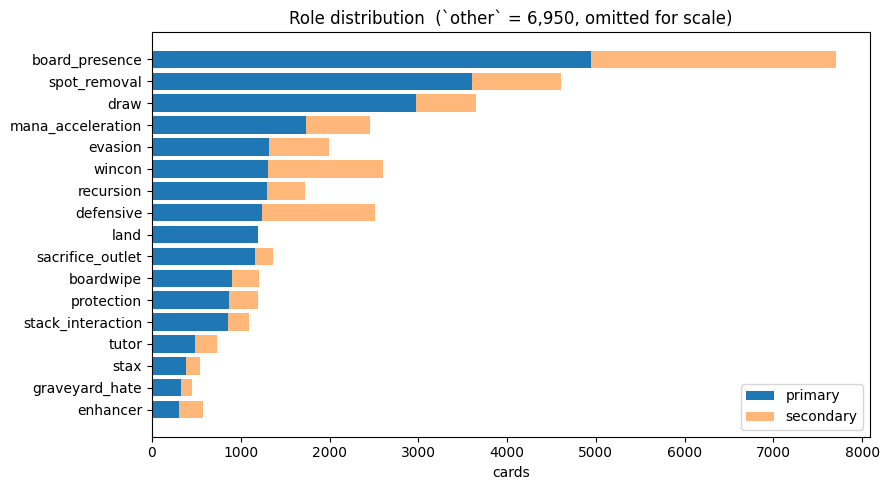

In [5]:
def overview() -> None:
    dist = R.role_distribution(roles)
    display(dist)

    agree = R.layer_agreement(roles)
    print("Tagger vs. oracle-text agreement, over the cards BOTH layers could read:")
    for k, v in agree.items():
        print(f"   {k:<18} {v if not isinstance(v, float) else round(v, 4)}")
    print("\n`n_heuristic_only` is what justifies keeping the text layer at all: cards Tagger never")
    print("tagged with anything the mapping recognises.")

    plot = dist[dist["role"] != "other"].sort_values("as_primary")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot["role"], plot["as_primary"], label="primary")
    ax.barh(plot["role"], plot["as_secondary"], left=plot["as_primary"], alpha=0.55,
            label="secondary")
    ax.set_xlabel("cards")
    other = int(dist.loc[dist["role"] == "other", "as_primary"].iloc[0])
    ax.set_title(f"Role distribution  (`other` = {other:,}, omitted for scale)")
    ax.legend()
    fig.tight_layout()
    plt.show()


overview()

### The 100 most-played cards

The population the recommender will actually see, and the main "does this look right" check.

In [6]:
show(find(sort="decks", limit=100), "Top 100 most-played cards in the corpus", limit=100)

## 4. Validation

150 well-known cards labeled with the primary role a player would name. **92 are flagged
`calibrated`** — their tag sets were read while writing the rules, so they are not independent
evidence; only the held-out number says anything about generalisation.

It reads 100% on both, and that is a number to be **suspicious of rather than pleased about**:
after three rounds of vocabulary revision most of this set was labeled from explicit instructions,
so it now measures "was the instruction implemented" far more than "does this generalise". The
distribution above and the tools in §5 are the checks that can still fail.

In [7]:
results = R.evaluate_spot_check(conn, roles)
for k, v in R.spot_check_accuracy(results).items():
    print(f"   {k:<22} {v if not isinstance(v, float) else round(v, 4)}")

misses = results.loc[~results["primary_ok"]]
display(misses[["name", "calibrated", "expected_primary", "actual_primary", "actual_secondary"]]
        if len(misses) else "no misses")

   n                      150
   n_unresolved           0
   primary_correct        150
   primary_accuracy       1.0
   n_held_out             58
   held_out_correct       58
   held_out_accuracy      1.0
   n_expected_secondary   17
   secondary_correct      17


'no misses'

Two cards in the set are **accepted 50/50 calls** rather than successes: Whispersilk Cloak scores
`protection` and `evasion` at *exactly* 4.0, and Teferi's Protection is tagged `fog` by Tagger so it
scores `defensive` over `protection`. Both readings are defensible, so they are labeled to the
tie-break's own answer and flagged `calibrated` — they are not evidence the mapping got them right.

One request could not be met at all: **Skullclamp's secondary should be `sacrifice_outlet`**, and no
signal exists. It carries no sacrifice tag and its text never says "sacrifice" — it kills X/1s via
−1 toughness. That is a real limit of tag-plus-text classification, not a tuning miss.

In [8]:
show(find(name="Whispersilk Cloak").iloc[[0]], "Accepted 50/50 calls", width=140)
show(find(name="Teferi's Protection").iloc[[0]], width=140)
explain("Skullclamp")

draw ◄,6.0 tag,3.0 text,tag draw +3 | tag draw-engine +1 | tag repeatable-draw +0.5 | tag pure-draw +0.5 | tag card-advantage +0.5 | tag repeatable-card-advantage +0.5 | text draw (a card|\w+ cards) +3


## 5. Dive into the data

The helper functions defined in §1, and what each one is for. The point of most of them is
**finding cards the mapping got wrong**.

#### Documentation

**Selecting**

- `find(role="draw")` — the one filter everything else uses. Combine any of `role`, `secondary`,
  `has_secondary`, `tag`, `name`, `source`, `min_decks`, `max_decks`, `sort`, `limit`
- `find(tag="sacrifice-outlet")` — by Scryfall tag (substring, so `tag="sacrifice"` catches all variants)
- `find(role="stax", sort="-score")` — **weakest evidence first**, where the mistakes are
- `find(secondary="mana_acceleration", min_decks=100)` — by *secondary* role
- `find_card("Skullclamp")` — one card, fuzzy-matched

**Looking**

- `show(find(role="enhancer"))` — render any result as a grid of card images
- `show("Krenko")` — shorthand for `show(find(name="Krenko"))`
- `explain("Skullclamp")` — **why** a card got its role: the card, its score per role, the exact
  tags and regexes responsible, and its full tag list

**Surveying**

- `list_roles()` — every role with counts, median score and examples
- `survey("wincon")` — a role at three depths: most-played, weakest, and layer disagreements
- `role_of_tag("sacrifice-outlet")` — which roles do the cards carrying a tag end up in?
- `tags_of("Ghalta, Primal Hunger")` — every tag on a card, rarest first, flagging which the rules use

**Hunting for mistakes**

- `disagreements("draw", min_decks=20)` — the two layers reached different roles. Highest-yield list
- `borderline(margin=0.5)` — primary beat secondary by ≤0.5; one weight change from flipping
- `thin_evidence(role="wincon")` — heavily-played cards holding a role on minimum evidence
- `audit_tag("sacrifice-outlet", "sacrifice_outlet")` — two-sided: tagged cards that missed the
  role, and cards in the role without the tag

**My own decks**

- `my_decks()` — the decklists in `data/fixtures/my_decks/`, by commander
- `deck_breakdown("kyler")` — role counts as `primary (secondary)`, then every card by role
- `load_deck("yenna")` — the deck as a DataFrame, joined to the role table

### Worked examples

Four short passes showing what each tool is for. Everything below is meant to be edited and re-run.

In [9]:
list_roles()

,role,primary,secondary,median_score,examples
0,land,1194,0,100.0,"Command Tower, Mountain, Plains, Forest"
1,stax,382,161,4.5,"Blood Moon, Thalia, Heretic Cathar, Thalia, Guardian of Thraben, Magus of the Moon"
2,boardwipe,896,307,6.0,"Blasphemous Act, Vandalblast, Toxic Deluge, Cyclonic Rift"
3,stack_interaction,852,243,4.0,"Counterspell, Deflecting Swat, An Offer You Can't Refuse, Arcane Denial"
4,spot_removal,3607,1002,3.5,"Swords to Plowshares, Path to Exile, Chaos Warp, Beast Within"
5,sacrifice_outlet,1155,211,5.0,"Skirk Prospector, Goblin Bombardment, Pashalik Mons, Siege-Gang Commander"
6,tutor,483,254,3.5,"Goblin Matron, Goblin Recruiter, Gamble, Enlightened Tutor"
7,mana_acceleration,1734,723,3.5,"Sol Ring, Arcane Signet, Cultivate, Fellwar Stone"
8,draw,2975,672,6.0,"Skullclamp, Faithless Looting, Conspicuous Snoop, Esper Sentinel"
9,recursion,1290,429,4.0,"Eternal Witness, Reanimate, Sun Titan, Animate Dead"


In [10]:
# A whole category at three depths -- most-played, weakest evidence, and layer disagreements.
survey("enhancer")

enhancer: 309 primary, 261 secondary, score 1.0-14.0 (median 3.0)


In [11]:
# Does a Scryfall tag do what its name says? This is how three misleading tags were caught:
# `mass-land-denial` means denial (Winter Orb) not destruction, `removal-land` sits on every
# "destroy target permanent", and `tax` means "something happens when an opponent does something"
# -- which is why Soul Warden was classifying as stax.
display(role_of_tag("sacrifice-outlet"))
display(role_of_tag("tax"))

1,383 cards match tag ~'sacrifice-outlet'


,cards,decks,examples
primary_role,,,
sacrifice_outlet,1153,38419,"Greta, Sweettooth Scourge, Ruthless Knave, Food Fight"
draw,84,1990,"Sanguine Spy, Skyclave Shadowcat, Nyssa of Traken"
land,45,3678,"Lotus Vale, Miren, the Moaning Well, Westvale Abbey // Ormendahl, Profane Prince"
boardwipe,29,286,"Solar Tide, Spontaneous Combustion, Lithobraking"
board_presence,21,750,"Pentavus, Fain, the Broker, Minsc & Boo, Timeless Heroes"
recursion,16,378,"Extus, Oriq Overlord // Awaken the Blood Avatar, Vexing Scuttler, Curious Forager"
stax,14,64,"Raze, Ember Swallower, Wildfire"
wincon,5,727,"Rite of Consumption, Grafted Butcher, Oni-Cult Anvil"
enhancer,3,338,"Buzzard-Wasp Colony, Arcade Cabinet, Mondrak, Glory Dominus"


482 cards match tag ~'tax'


,cards,decks,examples
primary_role,,,
draw,101,6945,"Tinybones, Trinket Thief, Search the Premises, Rocco, Street Chef"
board_presence,100,2474,"Tyranid Harridan, April O'Neil, Human Element, Shadow Puppeteers"
defensive,76,4034,"Soul's Attendant, Rewards of Diversity, Whipgrass Entangler"
other,33,323,"Vintara Elephant, Harmonious Grovestrider, Aether Barrier"
spot_removal,30,458,"Engulfing Slagwurm, Spelltithe Enforcer, Rishadan Cutpurse"
protection,21,733,"Twining Twins // Swift Spiral, Psychic Paper, Paladin's Arms"
mana_acceleration,19,4002,"Lotho, Corrupt Shirriff, Smothering Tithe, Treasure Nabber"
stack_interaction,16,316,"Detention Vortex, Divert, Nullhide Ferox"
wincon,16,364,"Polluted Bonds, Liesa, Shroud of Dusk, Trespasser's Curse"


In [12]:
# Two-sided audit of one tag/role pair. Both lists are worth reading: the first finds rules that
# are too weak, the second finds roles leaning on something other than the tag you assumed.
audit = audit_tag("sacrifice-outlet", "sacrifice_outlet", min_decks=50)
show(audit["tagged_but_not_in_role"], "Tagged `sacrifice-outlet` but classified elsewhere", limit=12)
show(audit["in_role_but_not_tagged"], "In `sacrifice_outlet` without the tag", limit=12)

tag ~'sacrifice-outlet': 1,383 cards   |   role 'sacrifice_outlet': 1,155 cards
  42 tagged cards NOT in the role   (>=50 decks)
  0 cards in the role WITHOUT the tag (>=50 decks)


In [13]:
# Near-coin-flip classifications: one weight change away from flipping.
show(borderline(margin=0.5, min_decks=100), "Borderline: primary beat secondary by ≤0.5", limit=12,
     caption=lambda r: f'{role_label(r)}<br><span style="color:#888">margin {r["margin"]}</span>')

In [14]:
# Cards holding a role on the minimum evidence the mapping allows. A real anchor is worth 3.0-5.0,
# so everything here got its role from corroborators alone -- exactly how `power-boost-to-all` once
# made every anthem effect a wincon.
show(thin_evidence(min_decks=200), "Thin evidence, but heavily played", limit=12)

### One of my own decks

`deck_breakdown(commander)` reads a decklist from `data/fixtures/my_decks/` and prints its role
counts as **`primary (secondary)`** — the reading order is land, draw, mana acceleration, removal
(spot removal + boardwipe + graveyard hate + stack interaction, broken out underneath), enhancer,
wincon, then everything else. This is the shape task 6.6's quotas will compare against.

In [15]:
display(my_decks())
deck_breakdown("kyler")

,commander,file
0,"Kyler, Sigardian Emissary",kyler.txt
1,"Orysa, Tide Choreographer",orysa.txt
2,"Yenna, Redtooth Regent",yenna.txt
3,"Yoshimaru, Ever Faithful",yoshimaru_bruse.txt


Kyler, Sigardian Emissary — 93 distinct cards, 99 copies

land                    39
draw                    16 (1)
mana_acceleration       10 (6)
removal                 13 (10)
    spot_removal         5 (9)
    boardwipe            7
    graveyard_hate       1
    stack_interaction    0 (1)
enhancer                 1 (1)
wincon                   0

board_presence           7 (9)
recursion                5 (2)
other                    3
sacrifice_outlet         2 (2)
protection               2 (1)
evasion                  1 (4)
stax                     0 (1)
tutor                    0 (2)
defensive                0 (3)


---

## Two notes on reading this notebook

**"Held-out" accuracy.** The labeled set splits in two. **Calibrated** cards are ones whose tags
were read *while writing the rules* — if a weight was chosen to get Cultivate right, Cultivate being
right afterwards proves nothing. **Held-out** cards were labeled from the card alone and never
looked at while tuning. Only the held-out number is evidence of generalisation, and after three
rounds of corrections most of this set is calibrated by construction — which is why §3's
distribution and §5's tools matter more than the accuracy figure.

**Editing.** This is the canonical copy and nothing regenerates it. Re-running it
(`jupyter nbconvert --execute --inplace`) replaces *outputs* but never *source*, so edits survive.

Every vocabulary decision, and the evidence behind it, is in the devlog's
*"Every vocabulary question, and how it was settled"* table:
[`docs/devlog/6.4-functional-roles.md`](../docs/devlog/6.4-functional-roles.md).

In [16]:
# Scratch cell -- run a helper here:

survey("board_presence")

board_presence: 4,945 primary, 2,755 secondary, score 1.0-11.0 (median 3.0)
